In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

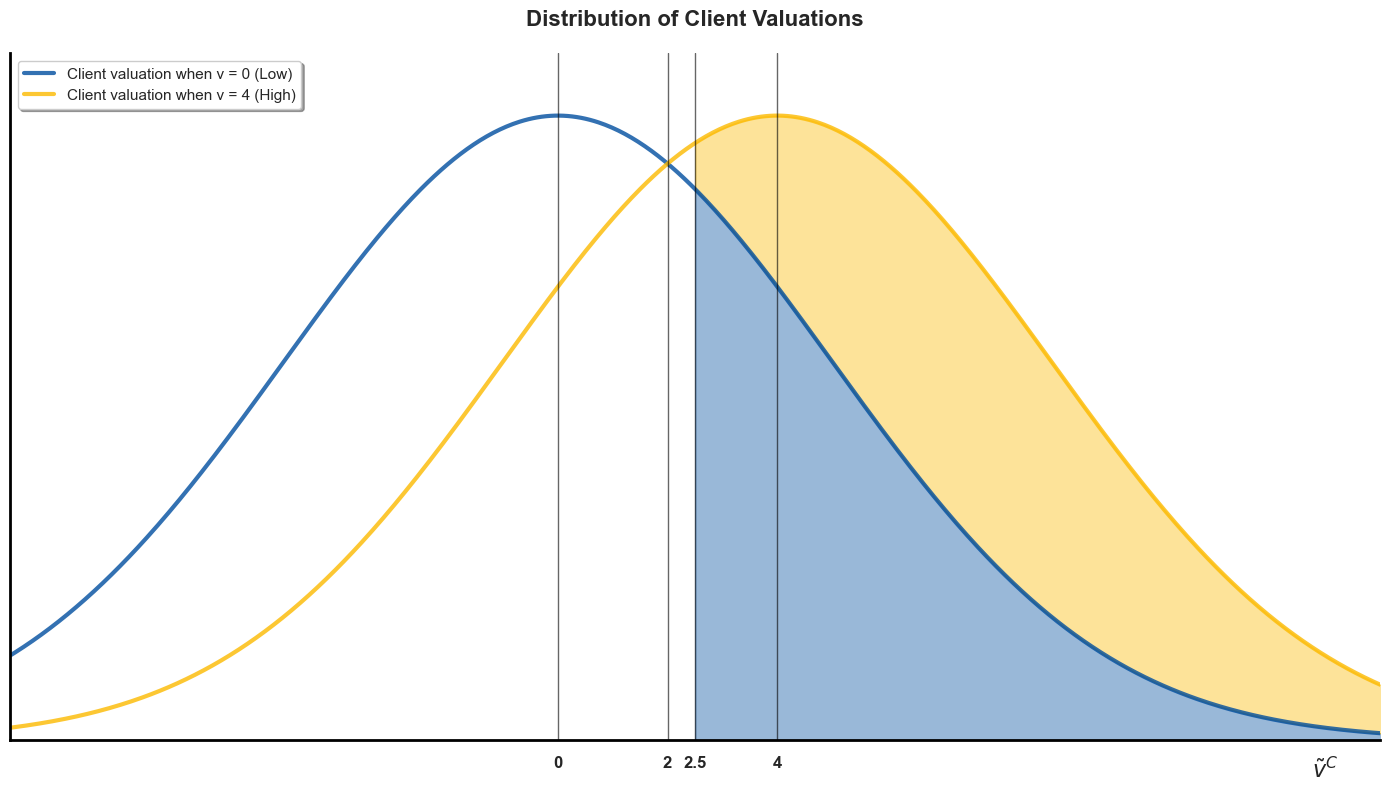

(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'Distribution of Client Valuations'}>)

In [3]:
def dual_normal(): 
    unibonn_blue = '#004E9F'
    unibonn_yellow = '#FCBA00'
    # Seaborn style
    sns.set_style('whitegrid') 
    plt.rcParams['figure.figsize'] = (12,8)
    # Parameters
    v_l = 0
    v_h = 4
    sigma = 5
    # X values
    x = np.linspace(-20, 20, 1000)
    #Distributions
    norm_l = stats.norm(v_l, sigma)
    norm_h = stats.norm(v_h, sigma)
    pdf_l = norm_l.pdf(x)
    pdf_h = norm_h.pdf(x)
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Plot the curves
    ax.plot(x, pdf_l, color=unibonn_blue, linewidth=3, 
            label='Client valuation when v = 0 (Low)', alpha=0.8)
    ax.plot(x, pdf_h, color=unibonn_yellow, linewidth=3, 
            label='Client valuation when v = 4 (High)', alpha=0.8)
    
    # Fill areas >= 2.5 separately for each curve
    x_fill = x[x >= 2.5]
    pdf_fill_l = norm_l.pdf(x_fill) 
    pdf_fill_h = norm_h.pdf(x_fill)
    
    # Find intersection points to separate the regions
    min_pdf = np.minimum(pdf_fill_l, pdf_fill_h)
    
    # Fill lightblue: from 0 to min(lightblue, lightcoral) everywhere, plus from min to lightblue where lightblue > lightcoral
    ax.fill_between(x_fill, 0, min_pdf, alpha=0.4, color=unibonn_blue)
    ax.fill_between(x_fill, min_pdf, pdf_fill_l, where=(pdf_fill_l >= pdf_fill_h), 
                    alpha=0.4, color=unibonn_blue, interpolate=True)
    
    # Fill lightcoral: from min to lightcoral where lightcoral > lightblue  
    ax.fill_between(x_fill, min_pdf, pdf_fill_h, where=(pdf_fill_h > pdf_fill_l), 
                    alpha=0.4, color=unibonn_yellow, interpolate=True)
    
    line_positions = [0, 2, 2.5, 4]
    for pos in line_positions:
        ax.axvline(x=pos, color='black', linestyle='-', alpha=0.6, linewidth=1)
        ax.text(pos, -0.002, f'{pos}', 
                ha='center', va='top', fontsize=12, fontweight='bold')
    
    # Remove axis labels
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('Distribution of Client Valuations', 
                fontsize=16, fontweight='bold', pad=20)
    
    # Remove grid
    ax.grid(False)
    
    # Remove tick labels but keep ticks
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    
    # Add clean black axes lines
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Beautiful legend
    ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True, fontsize=11)
    ax.text(14, -0.002, r'$\tilde{v}^C$', 
           ha='center', va='top', fontsize=16, fontweight='bold')
    # Set limits
    ax.set_xlim(-10, 15)
    ax.set_ylim(0, max(max(pdf_l), max(pdf_h)) * 1.1)
    plt.tight_layout()
    plt.savefig('C:/Users/adigo/Desktop/Thesis folder/Masters_Thesis/fig2.pdf', 
            bbox_inches='tight', dpi=300)
    plt.show()
    
    return fig, ax

dual_normal()